In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

#rdkit warn off
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Skin Irritation\dataset\train_set_skin_irritation_features_rdkitcdk.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

# Modred handling calc
if 'Modred_Descriptor' in train_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    train_df['Modred_Descriptor'] = train_df['Modred_Descriptor'].apply(string_to_list_float)

print("Train DataFrame:")
print(train_df.head())
print(train_df.keys())


Train DataFrame:
  Outcome RowID                                 Morgan_Descriptors  \
0       1    57  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
1       1   205  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2       0   445  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3       0   379  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4       1   110  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor   ID  \
0  [-0.49982639580295857, -1.084992491992044, -1....   57   
1  [-0.4178613599092674, 0.13371156740649162, 0.1...  205   
2  [-0.4106617898955919, 0.440720221747958

In [3]:
train_df

,Outcome,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,1,57,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.49982639580295857, -1.084992491992044, -1....",57,CCOCCCOC(O)CC,162.125594436,1.1580000000000001,68.31517003981556,...,1.0,3.0,10.0,0.4444444444444444,7.0,0.0,38.69,4.321928094887363,0.857,1.0
1,1,205,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4178613599092674, 0.13371156740649162, 0.1...",205,CC(C)CC(C)OP(=S)(S)OC(C)C,256.07205854200004,4.016900000000003,98.08278753362214,...,0.0,5.0,9.0,0.5,6.0,0.0,99.16,4.700439718141093,4.829000000000001,1.0
2,0,445,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4106617898955919, 0.4407202217479584, 0.50...",445,CC(C)(C)c1ccc(C#N)cc1,159.104799416,2.855780000000001,73.64869337294873,...,0.0,3.0,3.0,0.4285714285714285,1.0,0.0,23.79,4.584962500721156,3.5620000000000007,0.3636363636363636
3,0,379,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8141666872733075, -0.38901812751285475, -0...",379,C=Cn1ccnc1,94.053098192,0.9835999999999999,42.11046420466207,...,0.0,2.0,2.0,0.5,1.0,0.0,17.82,3.807354922057604,0.7189999999999999,0.0
4,1,110,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6957883439207186, 0.02886774372723733, 0.0...",110,CO[Si](OC)(OC)OC,152.05048539400002,0.007599999999999829,56.162559650057005,...,0.0,0.0,5.0,0.5,4.0,0.0,36.92,4.0,0.208,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,0,307,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.932053295431659, 1.0888498501770312, 1.0071...",307,CC1=NN(c2ccccc2)C(=O)/C1=N/Nc1ccc(-c2ccc(N/N=C...,622.1399273680001,7.041600000000004,262.52136273165746,...,2.0,0.0,2.0,0.48,7.0,2.0,114.12,6.614709844115208,8.981999999999998,0.0625
436,0,342,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.1499050992731923, 1.5597216913092669, 1.636...",342,Cc1ccc2[nH]c3cc4c(=O)c5cc(C)ccc5[nH]c4cc3c(=O)...,340.12117775199994,4.292840000000003,147.65028563721154,...,2.0,0.0,0.0,0.4615384615384615,0.0,1.0,65.72,5.906890595608519,7.008,0.0909090909090909
437,0,463,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.018564746005525636, 0.6431375900855004, 0.3...",463,CCCCCC1C(=O)CCC1CC(=O)OC,226.156894564,2.725100000000001,97.54931467665402,...,0.0,5.0,5.0,0.5,7.0,0.0,43.370000000000005,5.0,2.655,0.8461538461538461
438,1,218,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.15969601443774015, 0.9458664461470997, 1.0...",218,C=CCOC(=O)C1C(C)CCCC1(C)C,210.161979944,3.1780000000000017,92.698189544426,...,0.0,3.0,6.0,0.5,4.0,0.0,26.3,4.906890595608519,4.391,0.7692307692307693


In [4]:
train_df= train_df.sort_values(['Outcome'], ascending=True)
#train_df['RowID'] = train_df.index
train_df.head(100)

,Outcome,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
439,0,311,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3.1169985226416057, 0.8038501231707679, 0.869...",311,COc1ccc(NC(=O)/C(=N/Nc2ccc(-c3ccc(N/N=C(\C(C)=...,688.16038804,6.6688000000000045,285.6621839412296,...,4.0,4.0,5.0,0.4827586206896552,15.0,3.0,159.57999999999998,6.672425341971496,11.06,0.1176470588235294
169,0,471,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8209384939334945, -1.1381678094099636, -1....",471,CCOC(=O)CC#N,113.047678464,0.46318,47.866666496435336,...,0.0,3.0,7.0,0.5,3.0,0.0,50.09,3.807354922057604,-0.0239999999999999,0.6
350,0,483,"[0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.08124978430701464, 0.7906430880924455, 0.8...",483,CCC(CC)CC1(C(=O)O)CCCCC1,212.177630008,3.847800000000002,93.0684810992994,...,1.0,5.0,5.0,0.4285714285714285,5.0,0.0,37.3,4.906890595608519,4.818,0.9230769230769232
171,0,389,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2647432853628807, 1.155408661307298, 0.779...",389,O=Cc1cccc2c1OC(F)(F)O2,186.012850428,1.8205999999999996,71.87513955967094,...,0.0,0.0,2.0,0.5,1.0,0.0,35.53,4.807354922057604,1.915,0.125
172,0,337,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.0074553277658636, 1.6379482248483923, 1.716...",337,Cc1cc(C)c(Nc2ccc(Nc3c(C)cc(C)cc3C)c3c2C(=O)c2c...,474.23072819999993,7.799720000000007,211.9391600666363,...,2.0,0.0,0.0,0.4666666666666667,4.0,1.0,58.2,6.321928094887363,7.31,0.1875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,0,393,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.49982639580295857, -1.0849924919920417, -1...",393,C=CC(=O)NCOCCCC,157.11027872,1.0628,67.42917230958022,...,1.0,4.0,10.0,0.4444444444444444,7.0,0.0,38.33,4.321928094887363,1.2990000000000002,0.625
213,0,436,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.16107563113077308, 1.760296803470762, 1.371...",436,CC1C2CC(CC2C2CCC(O)CC2)C1(C)C,236.21401551600002,3.855800000000003,105.99012303538699,...,1.0,0.0,0.0,0.4444444444444444,1.0,1.0,20.23,5.247927513443585,6.01,1.0
214,0,321,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.31808477227625076, 0.7037688883054578, 0.76...",321,C=CCOC(=O)C(C)(C)OC(=O)c1cc(N)ccc1Cl,297.076785672,2.5868,121.85462858548127,...,1.0,3.0,9.0,0.4545454545454545,7.0,0.0,78.62,5.321928094887363,2.717,0.2857142857142857
327,0,417,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2689332319795547, 0.7723099185293252, 0.455...",417,CCCCCC1=C(OC(C)=O)CCC1CC(=O)OC,268.167459248,3.357000000000002,114.70314110276986,...,0.0,5.0,5.0,0.5,9.0,0.0,52.60000000000001,5.247927513443585,2.8040000000000003,0.7333333333333333


Classes                          :  ['0' '1']
Number of cpds in each class     :  [212, 228]
Total number of cpds             :  440
Class mapping:  {0: 0, 1: 1}


{0: 0, 1: 1}

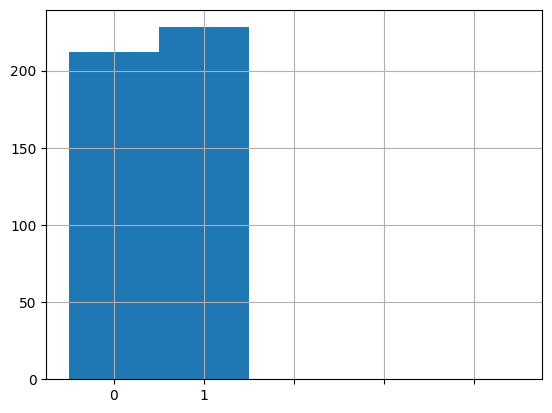

In [5]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create the label encoder
le = LabelEncoder()

# Get unique outcomes
outcomes = np.unique(train_df['Outcome'])
le.fit(list(set(outcomes)))

# Transform the 'Outcome' column
y = le.transform(train_df['Outcome'])

# Print class information
print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", [len(y[y == smi]) for smi in np.unique(y)])
print("Total number of cpds             : ", len(y))

# Explicitly map the outcome classes
S = train_df['Outcome']

# Ensure the class mapping is applied explicitly and consistently
info = {0: 0, 1: 1}  # Ensure '0' is mapped to 0 and '1' is mapped to 1
S = S.replace(info)

# Print the class replacement info for reference
print("Class mapping: ", info)

#GRAPH MATRIX
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info


In [6]:
y = S.astype(float).astype(np.int32).values
x = np.array(train_df['MACCS_Descriptors'].tolist())

In [7]:
# Random Forest – balanced & controlled (Morgan FP friendly)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
import numpy as np

paramgrid = {
    "n_estimators": [120],  # cukup stabil, tidak berat
    "max_features": [
        int(np.sqrt(x.shape[1])),     # konservatif
        int(x.shape[1] / 6)           # lebih ketat (FP reduction)
    ],
    "max_depth": [6, 8, 10],          # ⬅️ kontrol kompleksitas
    "min_samples_leaf": [3, 5, 8],    # ⬅️ stabilkan daun
    "min_samples_split": [10, 20]     # ⬅️ paksa split bermakna
}

cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

kappa_scorer = make_scorer(cohen_kappa_score)

model_rf_morgan = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=24,
        n_jobs=1
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1
)

model_rf_morgan.fit(x, y)

best_model_rf_morgan = model_rf_morgan.best_estimator_


Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [12]:
#Random Forest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_rf_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_morgan.predict(X_test)
    y_proba = best_model_rf_morgan.predict_proba(X_test)[:, 1]  
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[28 15]
 [13 32]]
Confusion Matrix for Fold 2:
[[30 13]
 [10 35]]
Confusion Matrix for Fold 3:
[[25 17]
 [10 36]]
Confusion Matrix for Fold 4:
[[24 18]
 [12 34]]
Confusion Matrix for Fold 5:
[[28 14]
 [12 34]]
Overall CV Accuracy: 0.6954545454545455
Overall CV AUC: 0.7613263357247179
Overall CV Precision: 0.6902885001389618
Overall CV Recall (Sensitivity): 0.7499516908212559
Overall CV F1 Score: 0.7185789759136677
Overall CV Specificity: 0.6364341085271318
Overall CV PPV (Positive Predictive Value): 0.6902885001389618
Overall CV NPV (Negative Predictive Value): 0.7027758420441348
Overall CV CCR (Correct Classification Rate): 0.693192899674194


In [8]:
# SVM 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
    "kernel": ["rbf"],
    "C": [0.5, 1, 2],          
    "gamma": [0.01, 0.05, 0.1] 
}

# 5-fold
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Cohen’s Kappa 
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights="quadratic"
)

# GridSearchCV
model_svm_morgan = GridSearchCV(
    estimator=SVC(
        probability=True,
        class_weight="balanced",
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    refit=True,
    verbose=1,
    n_jobs=1
)

# Train
model_svm_morgan.fit(x, y)

best_model_svm_morgan = model_svm_morgan.best_estimator_


Fitting 5 folds for each of 9 candidates, totalling 45 fits


In [9]:
# XGB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
    "max_depth": [3, 4, 5],          # kontrol kompleksitas
    "n_estimators": [200],           # stabil
    "learning_rate": [0.03, 0.05],   # lebih smooth
    "subsample": [0.8],              # cegah overfitting
    "colsample_bytree": [0.6, 0.8],  # cocok untuk fitur Morgan
    "reg_alpha": [0, 0.5],           # L1 regularization
    "reg_lambda": [1, 2]             # L2 regularization
}

# 5-fold stratified CV
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Cohen's Kappa (tanpa quadratic, lebih tepat untuk binary)
kappa_scorer = make_scorer(cohen_kappa_score)

model_xgb_morgan = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=24,
        n_jobs=1
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1
)

# Train
model_xgb_morgan.fit(x, y)

# Best model
best_model_xgb_morgan = model_xgb_morgan.best_estimator_


Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [23]:
#Neural Network 
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid
paramgrid_nn = {
    "hidden_layer_sizes": [(100,), (100, 50)],  # Arsitektur 
    "activation": ['relu', 'tanh'],             # fungsi aktivasi 
    "solver": ['adam', 'lbfgs'],              
    "alpha": [0.0001]                          
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_nn_morgan = GridSearchCV(
    estimator=MLPClassifier(max_iter=1000, random_state=42),
    param_grid=paramgrid_nn,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# Fit the model
model_nn_morgan.fit(x, y)
best_model_nn_morgan = model_nn_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [26]:
# LGBM
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid
paramgrid = {
    "n_estimators": [200],
    "learning_rate": [0.05],
    "max_depth": [4, 6],


    "num_leaves": [15, 31],
    "min_child_samples": [20, 40],


    "feature_fraction": [0.7, 0.9],
    "bagging_fraction": [0.7, 0.9],
    "bagging_freq": [1]
}

# Cross-validato
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights='quadratic'
)

# GridSearchCV
model_lgbm_morgan = GridSearchCV(
    estimator=LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        verbosity=-1,
        force_row_wise=True,
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# Train
model_lgbm_morgan.fit(x, y)
best_model_lgbm_morgan = model_lgbm_morgan.best_estimator_


Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [13]:
#SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_svm_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_morgan.predict(X_test)
    y_proba = best_model_svm_morgan.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[28 15]
 [10 35]]
Confusion Matrix for Fold 2:
[[29 14]
 [12 33]]
Confusion Matrix for Fold 3:
[[26 16]
 [10 36]]
Confusion Matrix for Fold 4:
[[25 17]
 [ 9 37]]
Confusion Matrix for Fold 5:
[[27 15]
 [16 30]]
Overall CV Accuracy: 0.6954545454545455
Overall CV AUC: 0.75822572102653
Overall CV Precision: 0.6892574407468024
Overall CV Recall (Sensitivity): 0.7500483091787439
Overall CV F1 Score: 0.7176535893005327
Overall CV Specificity: 0.6365448504983389
Overall CV PPV (Positive Predictive Value): 0.6892574407468024
Overall CV NPV (Negative Predictive Value): 0.7059164990094713
Overall CV CCR (Correct Classification Rate): 0.6932965798385414


In [14]:
#XGB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_xgb_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_morgan.predict(X_test)
    y_proba = best_model_xgb_morgan.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[30 13]
 [11 34]]
Confusion Matrix for Fold 2:
[[28 15]
 [ 9 36]]
Confusion Matrix for Fold 3:
[[25 17]
 [ 9 37]]
Confusion Matrix for Fold 4:
[[24 18]
 [ 9 37]]
Confusion Matrix for Fold 5:
[[24 18]
 [12 34]]
Overall CV Accuracy: 0.7022727272727274
Overall CV AUC: 0.7717750814515224
Overall CV Precision: 0.6882090440037875
Overall CV Recall (Sensitivity): 0.7806763285024155
Overall CV F1 Score: 0.7311362506259498
Overall CV Specificity: 0.6173864894795127
Overall CV PPV (Positive Predictive Value): 0.6882090440037875
Overall CV NPV (Negative Predictive Value): 0.7235395170832761
Overall CV CCR (Correct Classification Rate): 0.6990314089909642


In [24]:
#Neural Network NN
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model
    best_model_nn_morgan.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_nn_morgan.predict(X_test)
    y_proba = best_model_nn_morgan.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[30 13]
 [ 8 37]]
Confusion Matrix for Fold 2:
[[30 13]
 [14 31]]
Confusion Matrix for Fold 3:
[[28 14]
 [13 33]]
Confusion Matrix for Fold 4:
[[26 16]
 [10 36]]
Confusion Matrix for Fold 5:
[[26 16]
 [14 32]]
Overall CV Accuracy: 0.7022727272727274
Overall CV AUC: 0.7525335837064857
Overall CV Precision: 0.7011294946188562
Overall CV Recall (Sensitivity): 0.7413526570048309
Overall CV F1 Score: 0.7201597885279691
Overall CV Specificity: 0.6600221483942414
Overall CV PPV (Positive Predictive Value): 0.7011294946188562
Overall CV NPV (Negative Predictive Value): 0.7052881835038447
Overall CV CCR (Correct Classification Rate): 0.7006874026995361


In [27]:
# Evaluasi LGBM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

# Cross-validation setup
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Inisialisasi list metrik
accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model 
    best_model_lgbm_morgan.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_lgbm_morgan.predict(X_test)
    y_proba = best_model_lgbm_morgan.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[28 15]
 [12 33]]
Confusion Matrix for Fold 2:
[[28 15]
 [12 33]]
Confusion Matrix for Fold 3:
[[24 18]
 [12 34]]
Confusion Matrix for Fold 4:
[[23 19]
 [11 35]]
Confusion Matrix for Fold 5:
[[25 17]
 [15 31]]
Overall CV Accuracy: 0.6681818181818182
Overall CV AUC: 0.7409352079220634
Overall CV Precision: 0.6645655270655271
Overall CV Recall (Sensitivity): 0.7281159420289856
Overall CV F1 Score: 0.6945613715630384
Overall CV Specificity: 0.6033222591362126
Overall CV PPV (Positive Predictive Value): 0.6645655270655271
Overall CV NPV (Negative Predictive Value): 0.6736274509803921
Overall CV CCR (Correct Classification Rate): 0.665719100582599


In [29]:
import joblib
#SAVE PKL
#RF
joblib.dump(best_model_rf_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_RF_morgan.pkl',
    compress=9)
#SVM
joblib.dump(best_model_svm_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_SVM_morgan.pkl',
    compress=9)
#XGB
joblib.dump(best_model_xgb_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_XGB_morgan.pkl',
    compress=9)
#NN
joblib.dump(best_model_nn_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_NN_morgan.pkl',
    compress=9)
#LGBM
joblib.dump(best_model_lgbm_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_LGBM_morgan.pkl',
    compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_LGBM_morgan.pkl']

In [ ]:
usee thissss

In [ ]:
# RF
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_rf_from_pkl(test_df, rf_morgan, rf_maccs, rf_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :rf_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :rf_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :rf_modred.n_features_in_]

    return {
        "Morgan": rf_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  rf_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": rf_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }


# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_rf = predict_probabilities_rf_from_pkl(
    test_df,
    rf_morgan,
    rf_maccs,
    rf_modred
)

# Results
for model_name, y_prob in probs_rf.items():
    print(f"\n{model_name} RF Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_rf = consensus_probability(probs_rf)
consensus_metrics_rf = evaluate_model(y_true, consensus_probs_rf)

print("\nCONSENSUS RF (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_rf.items():
    print(f"{k}: {v}")
